### Ridge & Lasso Regression Using Algerian Forest Fire Dataset

In [1]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#loading dataset into dataframe 

df = pd.read_csv("datasets\\Algerian_forest_fires_dataset_UPDATE.csv", header=1)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
#checking for null values

df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [4]:
#creating another feature named as "region" with values sidi-bel abbes(1) and bejaia(0)

df.loc[:122,'region']= 0
df.loc[122:,'region']= 1

df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [5]:
df[['region']] = df[['region']].astype(int)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [6]:
#removing null value rows

df=df[~df.isnull().any(axis=1)]
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
region         0
dtype: int64

In [7]:
df.iloc[122]

day                    day
month                month
year                  year
Temperature    Temperature
 RH                     RH
 Ws                     Ws
Rain                 Rain 
FFMC                  FFMC
DMC                    DMC
DC                      DC
ISI                    ISI
BUI                    BUI
FWI                    FWI
Classes          Classes  
region                   1
Name: 123, dtype: object

In [8]:
#dropping this row 

df.drop(df.index[122], inplace=True)
df.iloc[122]

day                     01
month                   06
year                  2012
Temperature             32
 RH                     71
 Ws                     12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
region                   1
Name: 124, dtype: object

In [9]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'region'],
      dtype='str')

In [10]:
#fixing column names

df.columns = df.columns.str.strip()
df.columns 

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [11]:
df.dtypes

day              str
month            str
year             str
Temperature      str
RH               str
Ws               str
Rain             str
FFMC             str
DMC              str
DC               str
ISI              str
BUI              str
FWI              str
Classes          str
region         int64
dtype: object

In [12]:
#converting data type to int in given features

df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']]=df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)
df.dtypes



day            int64
month          int64
year           int64
Temperature    int64
RH             int64
Ws             int64
Rain             str
FFMC             str
DMC              str
DC               str
ISI              str
BUI              str
FWI              str
Classes          str
region         int64
dtype: object

In [13]:
#converting remaining feature values into floating type excluding 'Classes'.
string_features = [feature for feature in df.columns if df[feature].dtype.name=="str" and feature !="Classes"]
df[string_features]=df[string_features].astype(float)

Newer versions (>=1.0) introduced StringDtype, which is more consistent and avoids some quirks of 'object'.

In [14]:
df.dtypes

day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes            str
region           int64
dtype: object

In [15]:
#Saving the cleaned dataset

df.to_csv("datasets\\Algerain_forest_fires_dataset_cleaned.csv")

##### Exploratory Data Analysis (EDA)

In [16]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [17]:
#encoding 'Classes' feature

df['Classes'] = np.where(df['Classes'].str.contains("not fire"), 0, 1)


In [18]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

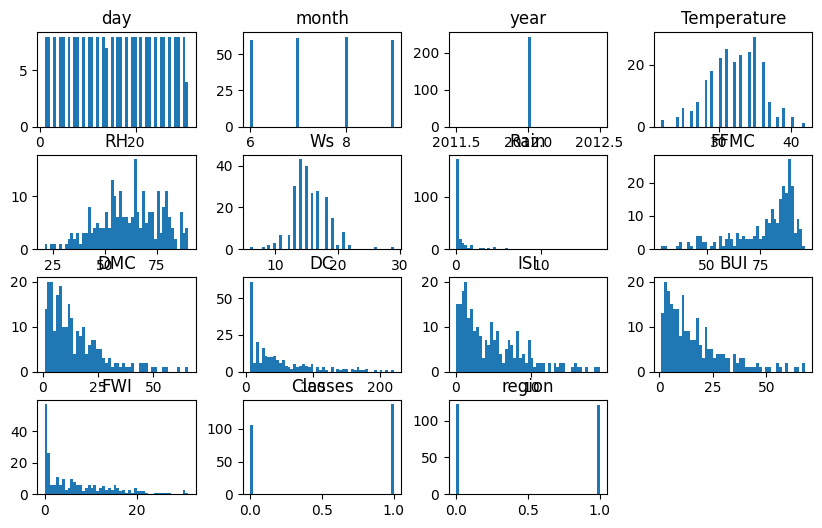

In [19]:
#plt.style.use("seaborn")
df.hist(bins=50, figsize=(10,6), grid=False)
plt.show()



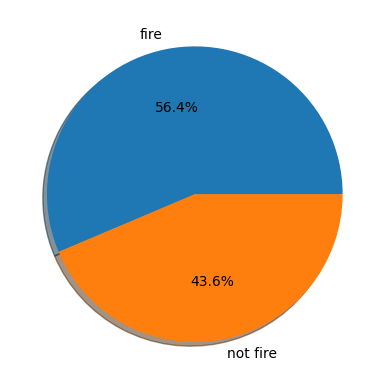

In [20]:
#pie chart on feature Classes

plt.pie(df['Classes'].value_counts(normalize=True), labels=['fire', 'not fire'], autopct='%1.1f%%', shadow=True)
plt.show()

<Axes: >

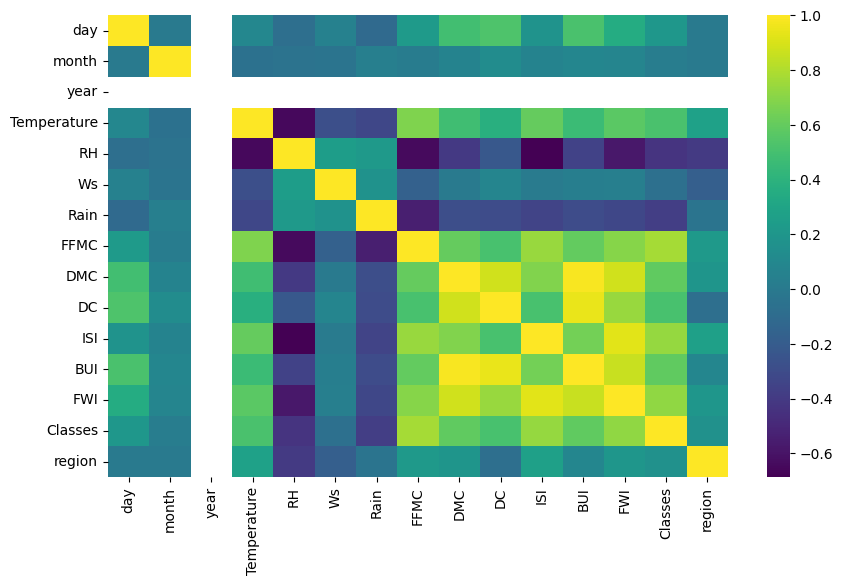

In [21]:
#Correlation check
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='viridis')

In [22]:
df['year'].value_counts()

year
2012    243
Name: count, dtype: int64

we can drop 'year' column since all datapoints are same

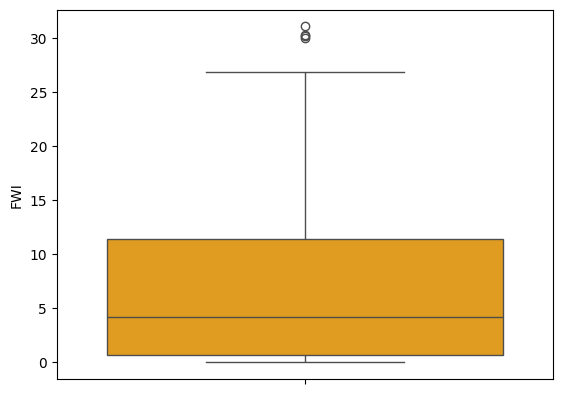

In [23]:
#boxplots

sns.boxplot(df['FWI'], orient="vertical", color="orange")
plt.show()

<Axes: xlabel='month', ylabel='count'>

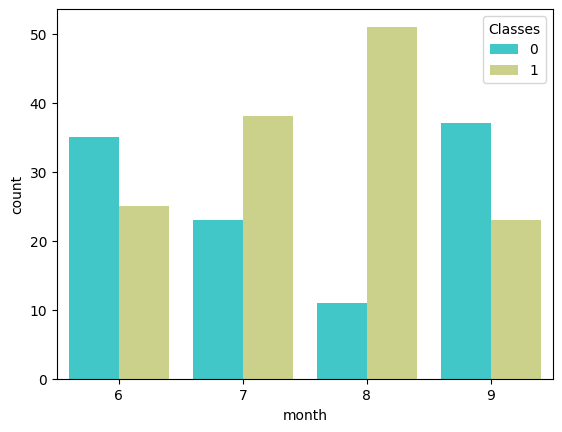

In [24]:
#monthly fire analysis

sns.countplot(x='month', hue='Classes', data=df, palette='rainbow')

#### Regression Model Training

In [25]:
#model will make prediction on FWI value given other features.
# will drop month, day and year columns

df = df.drop(['day', 'month', 'year'], axis=1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [26]:
#Independent and dependent features

x = df.drop(['FWI'], axis=1)
y = df['FWI']

In [27]:
#train and test data



<Axes: >

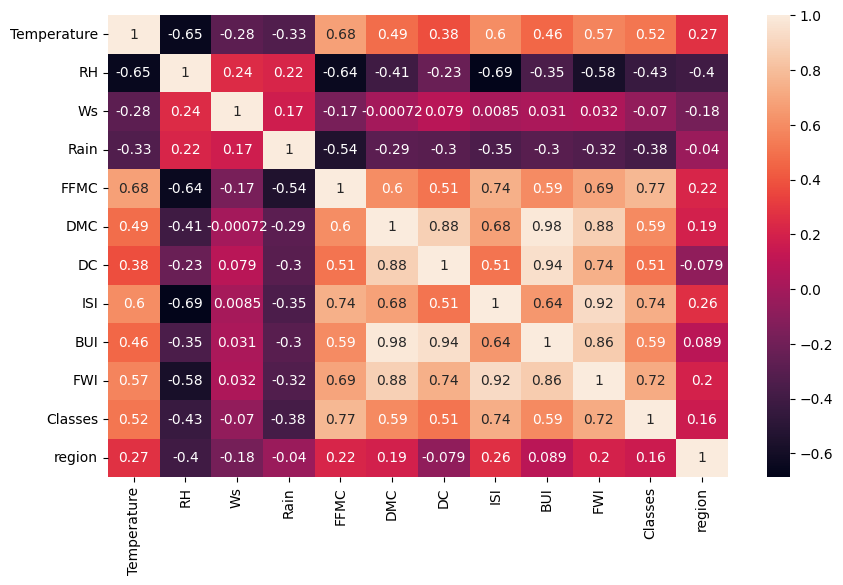

In [28]:
#checking for multi-colinearity
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)



In [29]:
def correlation_check(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr            


In [30]:
#for example, let's set threshold value as 0.85

correlated_features=correlation_check(x,0.85)

Threshold value is set by domain expert

In [31]:
#dropping one of the features which has high correlation

x=x.drop(list(correlated_features), axis=1)
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,region
0,29,57,18,0.0,65.7,3.4,1.3,0,0
1,29,61,13,1.3,64.4,4.1,1.0,0,0
2,26,82,22,13.1,47.1,2.5,0.3,0,0
3,25,89,13,2.5,28.6,1.3,0.0,0,0
4,27,77,16,0.0,64.8,3.0,1.2,0,0


In [32]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(182, 9)
(61, 9)
(182,)
(61,)


In [33]:
#feature scaling /standardization

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#### Boxplots to understand effect of Standardization

Text(0.5, 1.0, 'X Train After Scaling')

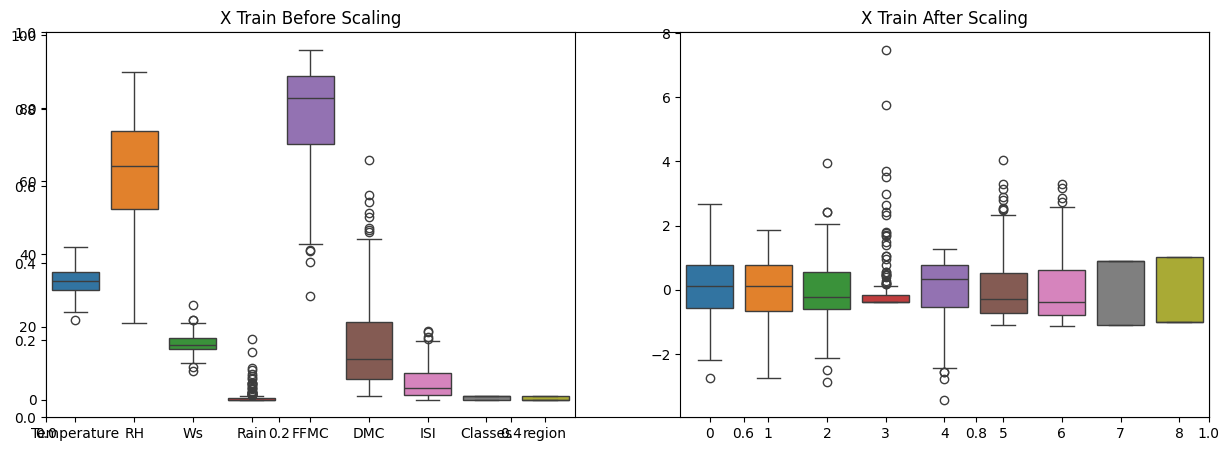

In [34]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("X Train Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("X Train After Scaling")

#### Model Training

#### Linear Regression

Mean absolute error: 0.546823646524997
R2 Score: 0.9847657384266951


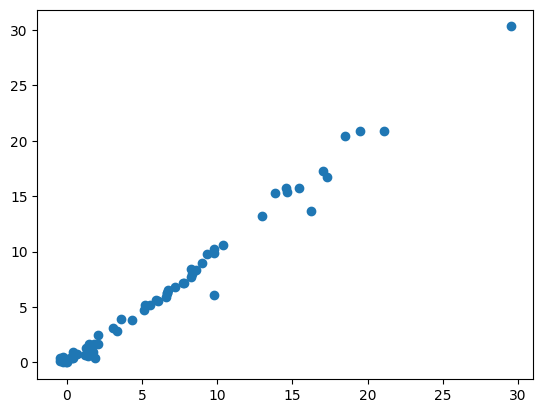

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

linear_regressor = LinearRegression()
linear_regressor.fit(x_train_scaled, y_train)
y_pred = linear_regressor.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"R2 Score: {r2_value}")

plt.scatter(y_pred, y_test)
plt.show()

#### Lasso Regression

Mean absolute error: 1.1331759949144087
R2 Score: 0.9492020263112388


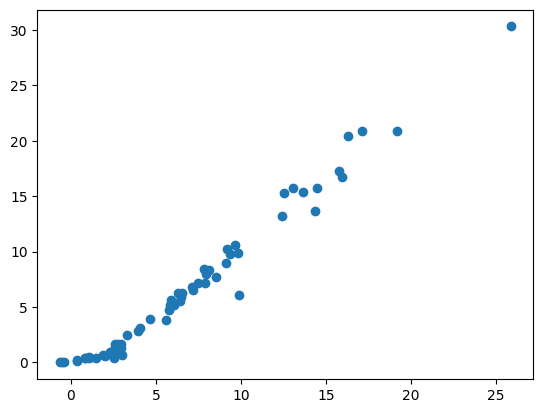

In [36]:
from sklearn.linear_model import Lasso

lasso_regressor = Lasso()
lasso_regressor.fit(x_train_scaled, y_train)
y_pred = lasso_regressor.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"R2 Score: {r2_value}")

plt.scatter(y_pred, y_test)
plt.show()

#### Ridge Regression

Mean absolute error: 0.5642305340105691
R2 Score: 0.9842993364555513


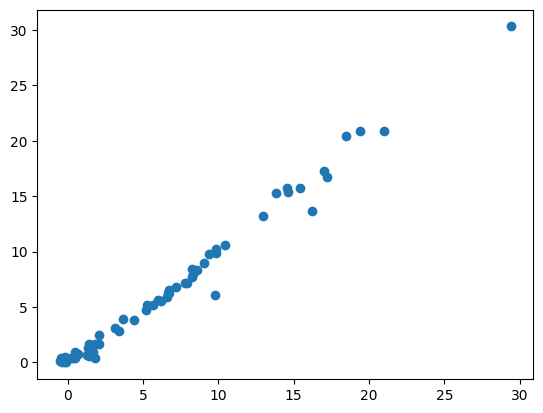

In [37]:
from sklearn.linear_model import Ridge

ridge_regressor = Ridge()
ridge_regressor.fit(x_train_scaled, y_train)
y_pred = ridge_regressor.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"R2 Score: {r2_value}")

plt.scatter(y_pred, y_test)
plt.show()

#### ElasticNet Regression

Mean absolute error: 1.8822353634895996
R2 Score: 0.8753460589519704


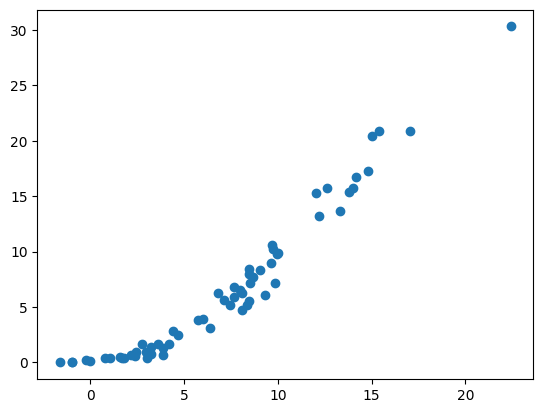

In [38]:
from sklearn.linear_model import ElasticNet

elasticnet_regressor = ElasticNet()
elasticnet_regressor.fit(x_train_scaled, y_train)
y_pred = elasticnet_regressor.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"R2 Score: {r2_value}")

plt.scatter(y_pred, y_test)
plt.show()

#### Hyper Parameter Tuning

In [39]:
from sklearn.linear_model import LassoCV

lassocv_obj = LassoCV()

In [40]:
lassocv_obj.fit(x_train_scaled, y_train)
y_pred_lassocv = lassocv_obj.predict(x_test_scaled)
y_pred_lassocv

array([ 8.16830389,  7.68147002, -0.23809698,  4.78348068,  6.80056553,
        1.8240148 ,  2.24891284,  7.65375452,  2.01837075,  3.43551694,
        0.65763521, 10.0012828 ,  9.37421682, 16.97541786, 18.25005429,
        1.67532586,  1.63417641, -0.73141894,  7.28096417,  3.12985293,
        2.00263648,  0.1674232 ,  6.47597673,  0.1299297 , 20.97550028,
        5.13544945,  5.85790118,  9.7488384 , -0.87894886,  9.92467295,
        6.71279503, -0.29032334, 10.29690182, 14.41231719,  1.75785569,
        0.89446894,  2.03030842,  5.98752495, -0.66008033, -0.60143063,
        6.46018173,  2.13349411,  8.46440838, -0.93165221, 15.40314151,
        8.32213695,  8.49346616,  1.4463523 , 13.02801863,  1.22072717,
       29.04392853,  5.51377627, 17.14332712, 19.2525866 , 13.68873198,
       16.02465131,  1.04280502,  9.09699018,  3.86335958, 14.44065137,
        5.24516066])

In [42]:
lassocv_obj.alpha_

np.float64(0.06582808719529475)

In [44]:
#number of alpha values it tried on
lassocv_obj.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039